 TensorRT is a high-performance deep learning inference optimizer and runtime library developed by NVIDIA. 
 It is designed to accelerate the inference phase of deep learning models, especially on NVIDIA GPUs
 So In this we will convert our existing Bifernet onnx model to trt ,test and compare it .


In [1]:
!pip install tensorrt==10.1.0, cuda-python==12.6.0, opencv-python-headless

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Installing build dependencies ... one
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.2/24.2 MB 3.7 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 5.5 MB/s eta 0:00:00a 0:00:01
  Created wheel for tensorrt: filename=tensorrt-10.1.0-py2.py3-none-any.whl size=16334 sha256=2b9842c3defeb7ad91f14ba92b601e463e7310aaec4cb4e3c56dfd1b799a3eee
  Stored in directory: /home/jovyan/.cache/pip/wheels/6c/fc/c4/7e30345c05db37c229e8c91c5e3de381dc2ea9707106d60519
  Created wheel for tensorrt-cu12: filename=tensorrt_cu12-10.12.0.36-py2.py3-none-any.whl size=17480 sha256=23ee30d50c17e2a8cebc5c6bbcd91eef02848208c8df986b0c2560f95dd0afaf
  Stored in directory: /home/jovyan/.cache/pip/wheels/76/f7/e4/64a0965dcc74c067cee07482ef03cc18add0def626fb0ebc1c
  Created wheel for tensorrt_cu12_libs: filename=te

In [5]:
import os

import numpy as np
import tensorrt as trt
from tensorrt_bindings import Logger

def convert_onnx_to_engine(onnx_filename, engine_filename=None):
    logger = Logger(Logger.INFO)
    builder = trt.Builder(logger)
    network = builder.create_network(0)
    config = builder.create_builder_config()
    parser = trt.OnnxParser(network, logger)
    config.set_memory_pool_limit(trt.MemoryPoolType.WORKSPACE, 2 << 30)

    print("Parse ONNX file")
    with open(onnx_filename, 'rb') as model:
        if not parser.parse(model.read()):
            logger.log(trt.Logger.ERROR, "ERROR: Failed to parse onnx file")
            for err in range(parser.num_errors):
                logger.log(trt.Logger.ERROR, parser.get_error(err))
            raise RuntimeError("parse onnx file error")

    print("Building TensorRT engine. This may take a few minutes.")
    engine_bytes = builder.build_serialized_network(network, config)
    if engine_filename:
        with open(engine_filename, 'wb') as f:
            f.write(engine_bytes)

convert_onnx_to_engine("/home/jovyan/datafabric/birefnetgeneral-model/birefnet-general.onnx", "birefnet.trt")


Parse ONNX file[06/14/2025-18:15:13] [TRT] [I] The logger passed into createInferBuilder differs from one already provided for an existing builder, runtime, or refitter. Uses of the global logger, returned by nvinfer1::getLogger(), will return the existing value.
[06/14/2025-18:15:13] [TRT] [I] [MemUsageChange] Init CUDA: CPU +0, GPU +0, now: CPU 176, GPU 713 (MiB)
[06/14/2025-18:15:14] [TRT] [I] [MemUsageChange] Init builder kernel library: CPU +1578, GPU +4, now: CPU 1944, GPU 717 (MiB)

Building TensorRT engine. This may take a few minutes.
[06/14/2025-18:15:17] [TRT] [I] Local timing cache in use. Profiling results in this builder pass will not be stored.
[06/14/2025-18:15:19] [TRT] [I] Compiler backend is used during engine build.
[06/14/2025-18:18:59] [TRT] [I] Detected 1 inputs and 1 output network tensors.
[06/14/2025-18:19:01] [TRT] [I] Total Host Persistent Memory: 581104 bytes
[06/14/2025-18:19:01] [TRT] [I] Total Device Persistent Memory: 0 bytes
[06/14/2025-18:19:01] [TRT]

[06/14/2025-21:39:51] [TRT] [I] Loaded engine size: 1100 MiB
[06/14/2025-21:39:51] [TRT] [I] [MS] Running engine with multi stream info
[06/14/2025-21:39:51] [TRT] [I] [MS] Number of aux streams is 3
[06/14/2025-21:39:51] [TRT] [I] [MS] Number of total worker streams is 4
[06/14/2025-21:39:51] [TRT] [I] [MS] The main stream provided by execute/enqueue calls is the first worker stream
[06/14/2025-21:39:51] [TRT] [I] [MemUsageChange] TensorRT-managed allocation in IExecutionContext creation: CPU +0, GPU +2384, now: CPU 0, GPU 3472 (MiB)
 TensorRT Inference completed in 1.512 seconds
Background removed! Result saved to: test_no_bg.png
Original image:


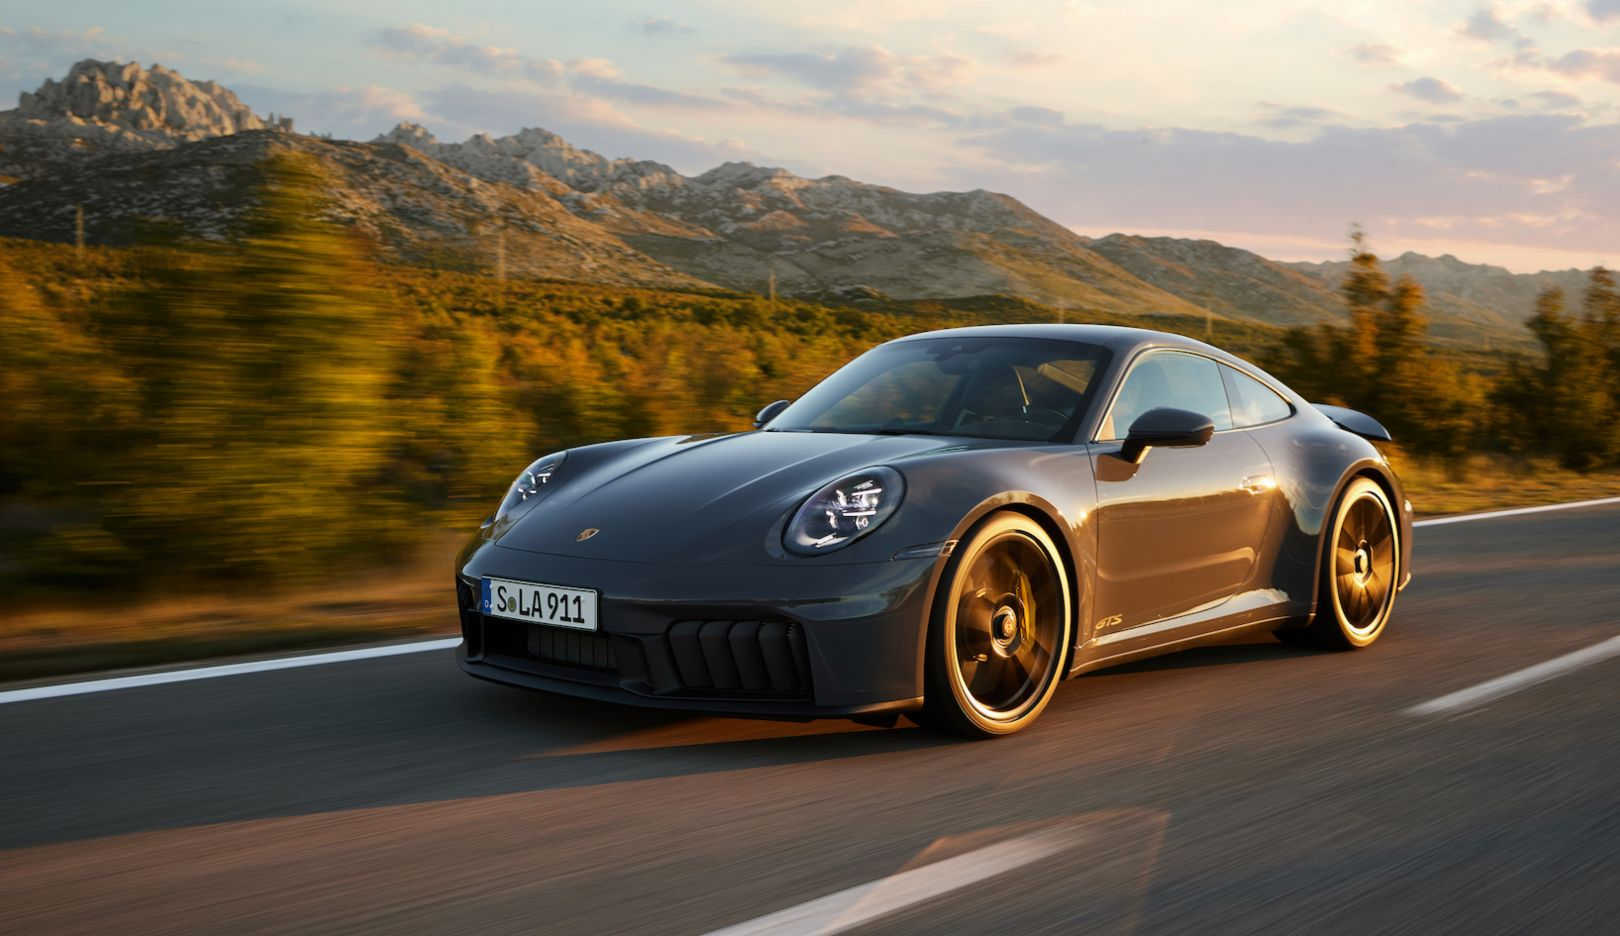

Result with background removed:


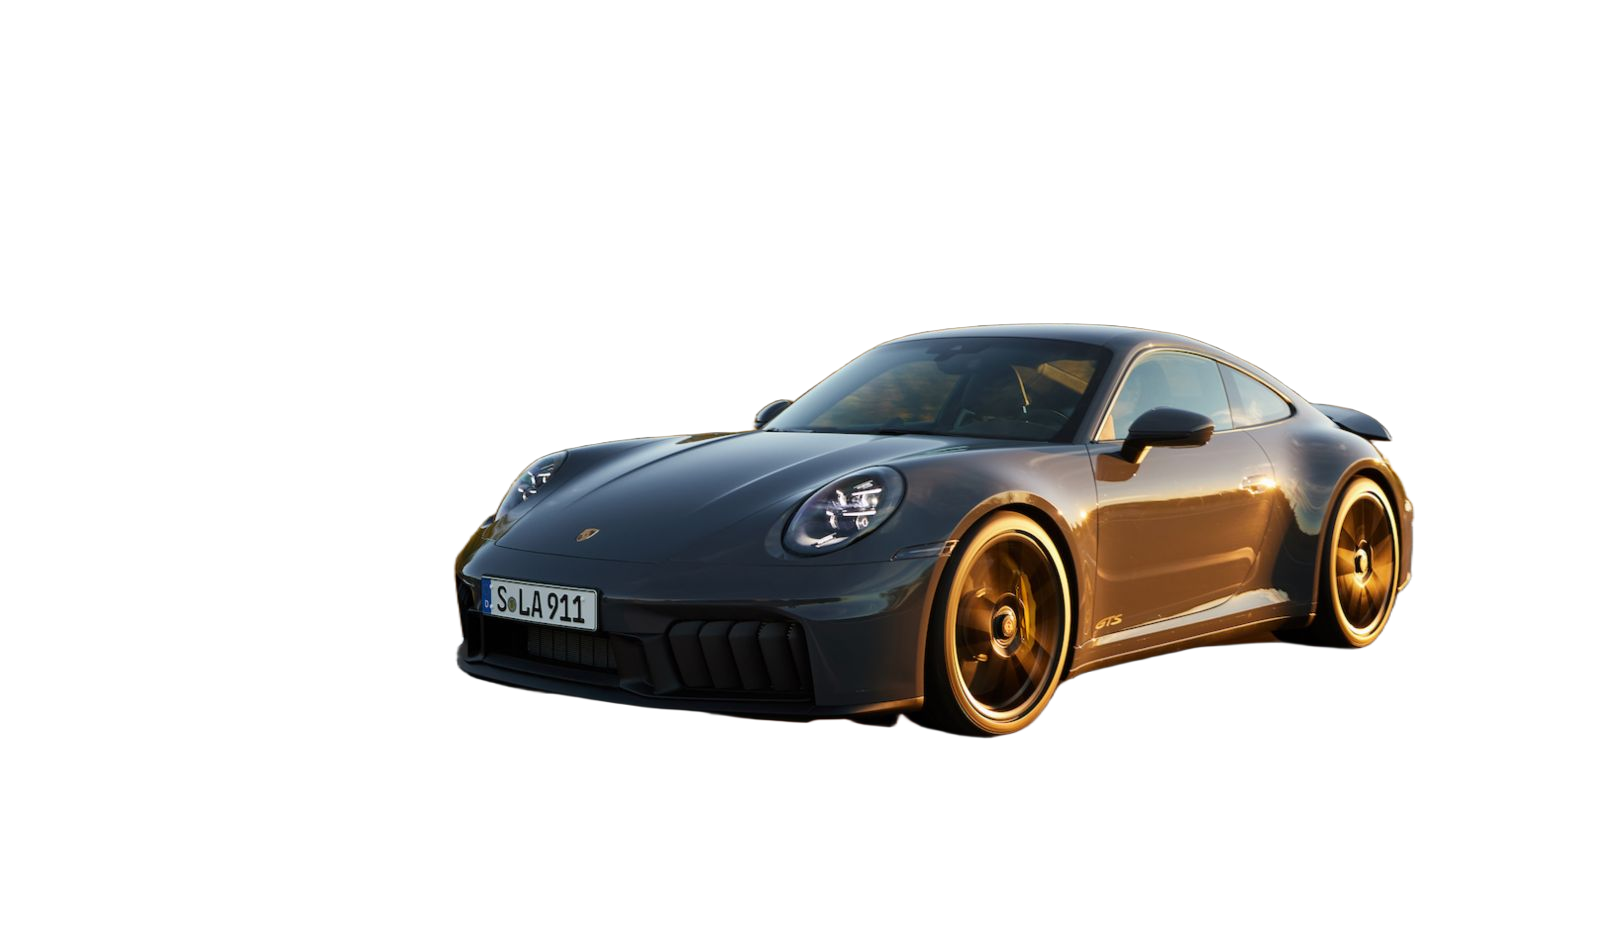

In [14]:
import cv2
import tensorrt as trt
from PIL import Image
import numpy as np
from torchvision import transforms
import ctypes
import os
from cuda import cuda, cudart

# Helper functions for CUDA memory management
def check_cuda_err(err):
    if isinstance(err, cuda.CUresult):
        if err != cuda.CUresult.CUDA_SUCCESS:
            raise RuntimeError("Cuda Error: {}".format(err))
    if isinstance(err, cudart.cudaError_t):
        if err != cudart.cudaError_t.cudaSuccess:
            raise RuntimeError("Cuda Runtime Error: {}".format(err))

def cuda_call(call):
    err, res = call[0], call[1:]
    check_cuda_err(err)
    if len(res) == 1:
        res = res[0]
    return res

class HostDeviceMem:
    def __init__(self, size: int, dtype=None):
        dtype = dtype or np.dtype(np.uint8)
        nbytes = size * dtype.itemsize
        host_mem = cuda_call(cudart.cudaMallocHost(nbytes))
        pointer_type = ctypes.POINTER(np.ctypeslib.as_ctypes_type(dtype))
        self._host = np.ctypeslib.as_array(ctypes.cast(host_mem, pointer_type), (size,))
        self._device = cuda_call(cudart.cudaMalloc(nbytes))
        self._nbytes = nbytes

    @property
    def host(self):
        return self._host

    @property
    def device(self):
        return self._device

    @property
    def nbytes(self):
        return self._nbytes

    def free(self):
        cuda_call(cudart.cudaFree(self.device))
        cuda_call(cudart.cudaFreeHost(self.host.ctypes.data))

def allocate_buffers(engine):
    inputs = []
    outputs = []
    bindings = []
    stream = cuda_call(cudart.cudaStreamCreate())
    
    for i in range(engine.num_io_tensors):
        tensor_name = engine.get_tensor_name(i)
        shape = engine.get_tensor_shape(tensor_name)
        size = trt.volume(shape)
        dtype = np.dtype(trt.nptype(engine.get_tensor_dtype(tensor_name)))
        
        # Allocate host and device buffers
        bindingMemory = HostDeviceMem(size, dtype)
        bindings.append(int(bindingMemory.device))
        
        if engine.get_tensor_mode(tensor_name) == trt.TensorIOMode.INPUT:
            inputs.append(bindingMemory)
        else:
            outputs.append(bindingMemory)
    
    return inputs, outputs, bindings, stream

def do_inference(context, engine, bindings, inputs, outputs, stream):
    # Transfer input data to GPU
    kind = cudart.cudaMemcpyKind.cudaMemcpyHostToDevice
    [cuda_call(cudart.cudaMemcpyAsync(inp.device, inp.host, inp.nbytes, kind, stream)) for inp in inputs]
    
    # Set tensor addresses
    for i in range(engine.num_io_tensors):
        context.set_tensor_address(engine.get_tensor_name(i), bindings[i])
    
    # Run inference
    context.execute_async_v3(stream_handle=stream)
    
    # Transfer results back to host
    kind = cudart.cudaMemcpyKind.cudaMemcpyDeviceToHost
    [cuda_call(cudart.cudaMemcpyAsync(out.host, out.device, out.nbytes, kind, stream)) for out in outputs]
    
    # Synchronize
    cuda_call(cudart.cudaStreamSynchronize(stream))
    return [out.host for out in outputs]

def sigmoid(x):
    return 1 / (1 + np.exp(-np.clip(x, -250, 250)))

def load_engine(engine_path):
    with open(engine_path, 'rb') as f:
        engine_data = f.read()
    return engine_data

# Main inference code
def remove_background(image_path, engine_path, output_path):
    import time
    start_time = time.time()
    # Load TensorRT engine
    logger = trt.Logger(trt.Logger.INFO)
    runtime = trt.Runtime(logger)
    engine = runtime.deserialize_cuda_engine(load_engine(engine_path))
    context = engine.create_execution_context()
    
    # Image preprocessing
    transform = transforms.Compose([
        transforms.Resize((1024, 1024)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    
    # Load and preprocess image
    origin_image = Image.open(image_path).convert("RGB")
    w, h = origin_image.size
    image_data = np.expand_dims(transform(origin_image), axis=0).astype(np.float32).ravel()
    
    # Allocate buffers and run inference
    inputs, outputs, bindings, stream = allocate_buffers(engine)
    np.copyto(inputs[0].host, image_data)
    trt_outputs = do_inference(context, engine, bindings, inputs, outputs, stream)
    
    # Post-process results
    pred = np.squeeze(sigmoid(trt_outputs[-1].reshape((1, 1, 1024, 1024))))
    
    # Resize mask to original image size
    mask_pil = transforms.ToPILImage()(pred)
    mask_resized = mask_pil.resize((w, h))
    
    # Apply mask to original image
    mask_array = np.array(mask_resized) / 255.0
    result_image = origin_image.copy()
    result_image.putalpha(Image.fromarray((mask_array * 255).astype(np.uint8)))
    
    # Save result
    result_image.save(output_path)
    
    # Clean up
    for mem in inputs + outputs:
        mem.free()
    cuda_call(cudart.cudaStreamDestroy(stream))
    
    total_time = time.time() - start_time
    print(f" TensorRT Inference completed in {total_time:.3f} seconds")
    print(f"Background removed! Result saved to: {output_path}")
    return result_image

result = remove_background("test.jpg", "birefnet.trt", "test_no_bg.png")

from IPython.display import Image as IPImage, display
print("Original image:")
display(IPImage("test.jpg"))
print("Result with background removed:")
display(IPImage("test_no_bg.png"))

Testing with inferring onnx vs Tensorrt model

In [5]:
!pip install onnxruntime-gpu

Preprocessing...
Testing ONNX only...
ONNX providers: ['CUDAExecutionProvider', 'CPUExecutionProvider']
ONNX Avg Time: 0.3353 sec
[06/14/2025-21:35:42] [TRT] [I] Loaded engine size: 1100 MiB
[06/14/2025-21:35:42] [TRT] [I] [MS] Running engine with multi stream info
[06/14/2025-21:35:42] [TRT] [I] [MS] Number of aux streams is 3
[06/14/2025-21:35:42] [TRT] [I] [MS] Number of total worker streams is 4
[06/14/2025-21:35:42] [TRT] [I] [MS] The main stream provided by execute/enqueue calls is the first worker stream
[06/14/2025-21:35:42] [TRT] [I] [MemUsageChange] TensorRT-managed allocation in IExecutionContext creation: CPU +0, GPU +2384, now: CPU 0, GPU 3472 (MiB)


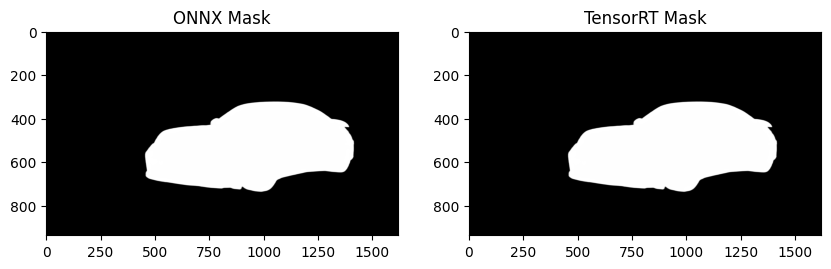

 ONNX Runtime (mean over 19 runs): 0.3353 sec
 TensorRT (mean over 19 runs): 0.1420 sec


In [13]:
from PIL import Image  
import onnxruntime as ort
import time
import matplotlib.pyplot as plt

# Helper to preprocess image once
def preprocess_image(image_path):
    image = Image.open(image_path).convert("RGB")
    transform = transforms.Compose([
        transforms.Resize((1024, 1024)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    tensor = transform(image).unsqueeze(0).numpy().astype(np.float32)
    return tensor, image

# Run ONNX inference multiple times
def benchmark_onnx(image_tensor, onnx_path, num_runs=20):
    session = ort.InferenceSession(onnx_path, providers=['CUDAExecutionProvider'])
    print("ONNX providers:", session.get_providers())
    input_name = session.get_inputs()[0].name

    times = []
    for i in range(num_runs):
        start = time.time()
        _ = session.run(None, {input_name: image_tensor})
        times.append(time.time() - start)

    pred = sigmoid(session.run(None, {input_name: image_tensor})[0].squeeze())
    return pred, times[1:]  # exclude first run

# Run TensorRT inference multiple times
def benchmark_tensorrt(image_tensor, original_image, engine_path, num_runs=20):
    logger = trt.Logger(trt.Logger.INFO)
    runtime = trt.Runtime(logger)
    engine = runtime.deserialize_cuda_engine(load_engine(engine_path))
    context = engine.create_execution_context()

    inputs, outputs, bindings, stream = allocate_buffers(engine)
    np.copyto(inputs[0].host, image_tensor.ravel())

    # Warm-up + timed runs
    times = []
    for i in range(num_runs):
        start = time.time()
        _ = do_inference(context, engine, bindings, inputs, outputs, stream)
        times.append(time.time() - start)

    pred = sigmoid(np.squeeze(outputs[-1].host).reshape((1024, 1024)))

    # Clean up
    for mem in inputs + outputs:
        mem.free()
    cuda_call(cudart.cudaStreamDestroy(stream))

    return pred, times[1:]  # exclude first run

print("Preprocessing...")
# Load image and preprocess once
image_tensor, orig_image = preprocess_image("test.jpg")

print("Testing ONNX only...")
# Run ONNX benchmark
onnx_mask, onnx_times = benchmark_onnx(image_tensor, "/home/jovyan/datafabric/birefnetgeneral-model/birefnet-general.onnx")

print(f"ONNX Avg Time: {np.mean(onnx_times):.4f} sec")
# Run TensorRT benchmark
trt_mask, trt_times = benchmark_tensorrt(image_tensor, orig_image, "birefnet.trt")

# Resize masks for comparison
onnx_mask_resized = Image.fromarray((onnx_mask * 255).astype(np.uint8)).resize(orig_image.size)
trt_mask_resized = Image.fromarray((trt_mask * 255).astype(np.uint8)).resize(orig_image.size)

# Plot results
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(onnx_mask_resized, cmap='gray')
axs[0].set_title("ONNX Mask")
axs[1].imshow(trt_mask_resized, cmap='gray')
axs[1].set_title("TensorRT Mask")
plt.show()

# Print timing summary
print(f" ONNX Runtime (mean over {len(onnx_times)} runs): {np.mean(onnx_times):.4f} sec")
print(f" TensorRT (mean over {len(trt_times)} runs): {np.mean(trt_times):.4f} sec")
